# CNN Transfer Learning: Cristiano Ronaldo Classifier

The goal of this project is to build a binary image classifier using **transfer learning** on a pretrained CNN from the Torchvision package. The classifier is trained to determine whether a given image is of **Cristiano Ronaldo** or not.

Rather than training a CNN from scratch, we use a model already pretrained on ImageNet and only fine-tune the final layers on our own dataset. 
This is done through a technique known as **transfer learning** that allows us to use the knowledge gained from the pre-trained model to adapt them to our classification task.

The dataset used in this project consists of images of Cristiano Ronaldo alongside images of other sports celebrities (Kane Williamson, Kobe Bryant, 
and Maria Sharapova), which **serve as the negative class.** Since our dataset is relatively small (only 109 images of Ronaldo), we use data augmentation techniques such as random flipping, rotation, and cropping during training.

The final model is deployed as a web application through **Streamlit.** This serves as a platform where a user can upload a facial image and get a prediction of whether the person is Cristiano Ronaldo or not.

## Import Libraries & Set Device

In [23]:
# libraries
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
from torchvision import datasets, transforms, models

from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device: ', device)

Using device:  cuda:0


## Load & Transform Data

We will load the dataset and apply **data augmentation** to the training set to artificially increase variety since we have a small dataset. This will ultimately aslo reduce overfitting. For validation, we will only normalize the data. 

Transforms follow the ImageNet normalization standard required by all pretrained models.

The reference can be found in the [PyTorch transforms documentation](https://pytorch.org/vision/stable/transforms.html).

The dataset is taken from Kaggle and can be found [here](https://www.kaggle.com/datasets/yaswanthgali/sport-celebrity-image-classification?select=Sports-celebrity+images)

In [3]:
# data transformation and augmentation 
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),       # crop and resize
        transforms.RandomHorizontalFlip(),       # flipping images
        transforms.ColorJitter(brightness=0.2, contrast=0.2),     # restructing images quality
        transforms.ToTensor(),   # converting to tensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])    # normalize by pretrained model requirements
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [4]:
# defining the directory
data_dir = 'images/celebrity_images'

# loading the full dataset from the directory
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['train'])

class_names = full_dataset.classes    # getting class names

print('Classes:', class_names)
print('Total images:', len(full_dataset))

Classes: ['Not_Ronaldo', 'Ronaldo']
Total images: 441


## Train/Val Split

The model expects the folder structure to have train and validation splits. Hence, we split the entire dataset.

In [5]:
# splitting randomly into train (80%) and val (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size  # remaining images 

# randomly splitting dataset into train and val
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print('Training size:', train_size)
print('Validation size:', val_size)

Training size: 352
Validation size: 89


## Creating DataLoaders

Now, we create dataloaders for both train and val sets with shuffle=True for training to prevent the model learning order of images. However, we do shuffle=False for validation since order doesn't matter during evaluation.

The reference was made from the github file for transfer learning but this is a bit different since we had to manually separate into train/val.

In [6]:
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4),
    'val': DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=4)
}

dataset_sizes = {'train': train_size, 'val': val_size}

## Visualize Training Data

This is an intermediatary step just to verify the data. Before training, we will visualize a batch of training images in order to ensure that the data has been loaded correctly and data augmentation has been applied properly.

For this, we take one random batch of images. We need to convert those initial inputs to numpy array and unnormalize it to be able to plot. We make use of the `imshow` function of the **matplotlib** library to display the images. The reference can be found in an example [here](https://matplotlib.org/stable/tutorials/images.html).

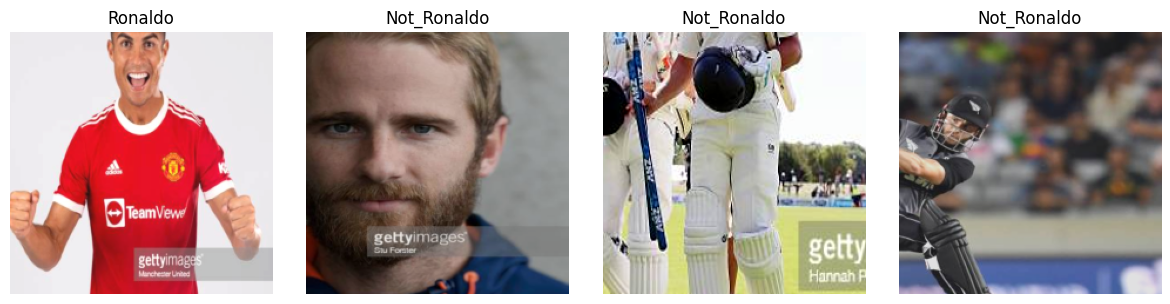

In [12]:
inputs, classes = next(iter(dataloaders['train']))     # get a batch of training images

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):                                     # since we have 4 images in one batch
    image = inputs[i].numpy().transpose((1, 2, 0))     # converting tensors to numpy
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean                         # undoing normalization
    image = np.clip(image, 0, 1)                       # all values stay within 0 and 1
    axes[i].imshow(image)                              # display image
    axes[i].set_title(class_names[classes[i]])         # show label
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Finetune the ResNet152 Model

This is the step where we apply **transfer learning**. We load a pretrained `ResNet152` model from PyTorch's torchvision package. The model was originally trained on [ImageNet](https://www.image-net.org/) with 1000 classes. We decided to choose ResNet152 over other pretrained models because upon checking the PyTorch API, it is the deepest and most accurate ResNet architecture with a Top-1 error rate of 21.69. This means that it is a strong model with about 80% Top-1 accuracy on ImageNet. So, I believe this will be the most effecient and accurate at capturing the facial features needed to distinguish Ronaldo from other athletes in the dataset.

What we will do now is, replace the final fully connected layer with a new one that outputs only 2 classes (Ronaldo / Not Ronaldo), then fine-tune the entire network. The references used can be found on the [github example](https://github.com/aleahy-work/CS-STAT323-W26/blob/main/ClassJupyter/class3-04-26-transfer.ipynb), the [video](https://www.youtube.com/watch?v=5rD8f1oiuWM), and the [documentation](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet152.html).

In [14]:
model = models.resnet152(weights='IMAGENET1K_V1')       # loading the model

num_ftrs = model.fc.in_features     # num of input features to final layer

model.fc = nn.Linear(num_ftrs, 2)   # final layer has 2 classes (Ronaldo/Not Ronaldo)

model = model.to(device)

criterion = nn.CrossEntropyLoss()   # loss function

optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)   # optimizing and fine tuning

scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)  # decay lr by 0.1 every 7 epochs

print("Final layer: ", model.fc)

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /home/sushrestha/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:02<00:00, 114MB/s]  


Final layer:  Linear(in_features=2048, out_features=2, bias=True)


## Train the Model

In this step, we will define a general training function `train_model` that handles both the training and validation phases each epoch. The function will also:
- Track and save the **best model weights** based on validation accuracy
- Use a **learning rate scheduler** to improve convergence over time

Some references made are from the [video](https://www.youtube.com/watch?v=5rD8f1oiuWM), this [Medium documenation](https://medium.com/@ebimsv/mastering-cnns-in-pytorch-week-2-building-and-training-custom-and-pretrained-cnns-for-image-f040572c73c1), and the github example. 

In [20]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs - 1}")
        print("-"*10)

        for phase in ['train', 'val']:   # each epoch has train and val phase
            if phase == 'train':
                model.train()       # set model to training model
            else:
                model.eval()        # set model to evaluation model

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:    # iterating over the data
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()      # reset gradients

                with torch.set_grad_enabled(phase == 'train'):   # forward pass where gradient is tracked only for training
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':      # only for training data
                        loss.backward()       # backpropagation
                        optimizer.step()      # updating weigths

                # tracking loss and acc
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()    # updating lr

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # saving model to disk if it's the best so far
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), 'best_model.pth')     # .pth only saves model weights to the current dir

        print()

    time_elapsed = time.time() - since
    print(f'Training time: {time_elapsed // 60:.0f}mins {time_elapsed % 60:.0f}secs')
    print(f'Best validation accuracy: {best_acc:.4f}')

    model.load_state_dict(torch.load('best_model.pth'))   # load best saved model weights before returning
    return model

In [21]:
# training the model with the function
model = train_model(model, criterion, optimizer, scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.3406 Acc: 0.8835
val Loss: 0.2387 Acc: 0.8876

Epoch 1/24
----------
train Loss: 0.3109 Acc: 0.8608
val Loss: 0.2687 Acc: 0.9213

Epoch 2/24
----------
train Loss: 0.3215 Acc: 0.8778
val Loss: 0.4940 Acc: 0.8652

Epoch 3/24
----------
train Loss: 0.2950 Acc: 0.8977
val Loss: 0.3566 Acc: 0.8989

Epoch 4/24
----------
train Loss: 0.3851 Acc: 0.8835
val Loss: 0.2423 Acc: 0.8764

Epoch 5/24
----------
train Loss: 0.2123 Acc: 0.9290
val Loss: 0.2391 Acc: 0.9101

Epoch 6/24
----------
train Loss: 0.2233 Acc: 0.9205
val Loss: 0.1271 Acc: 0.9438

Epoch 7/24
----------
train Loss: 0.2345 Acc: 0.9233
val Loss: 0.2026 Acc: 0.9326

Epoch 8/24
----------
train Loss: 0.1442 Acc: 0.9517
val Loss: 0.1089 Acc: 0.9551

Epoch 9/24
----------
train Loss: 0.1416 Acc: 0.9489
val Loss: 0.3454 Acc: 0.8989

Epoch 10/24
----------
train Loss: 0.1713 Acc: 0.9290
val Loss: 0.1056 Acc: 0.9663

Epoch 11/24
----------
train Loss: 0.1029 Acc: 0.9602
val Loss: 0.1151 Acc: 0.9326

Ep

## Model Evaluation & Summary

After training, we evaluate our model on the validation set using a **Confusion Matrix**. A confusion matrix summarizes the classification performance of our model. This gives a much more detailed picture of model performance compared to just accuracy alone, as it shows exactly where the model is making mistakes.

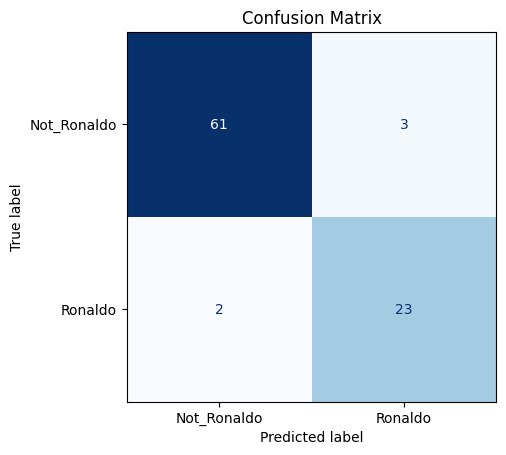

In [25]:
model.eval()   # setting to evaluation mode

# store all preds and true labels 
all_preds = []
all_labels = []

with torch.no_grad():     # disable gradient tracking
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # moving preds and labels to cpu and convertng to numpy
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# plotting cm
display.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.show()

***Evaluation Summary:***

From the results of the confusion matrix, we can conclude the following about the model performance:
- The model correctly classified **84 out 89** images in total, identifying **23 out of 25** Ronaldo images and **61 out of 64** Not Ronaldo images.
- The model incorrectly classified only **5 out 89** images in total, misidentifying **2 out of 25** Ronaldo images as Not Ronaldo images, and **3 out of 64** Not Ronaldo images as Ronaldo images.
- Overall accuracy is about **94.4%**.

Overall, the model performs very well given the small dataset size. This indicates that transfer learning with ResNet152 is a highly effective model for tasks such as facial image classification.